# Tech Layoffs — Exploratory Data Analysis

This notebook performs exploratory data analysis (EDA) on `layoffs.csv`, the raw dataset used in the [SQL data-cleaning project](README.md) in this repository.

The SQL script (`SQL cleaning data.sql`) handles the full production-grade cleaning workflow (staging tables, dedup via `ROW_NUMBER()`, standardization, null handling). Here, we replicate a lightweight version of that cleaning in pandas purely to make the data analysis-ready, then explore trends across time, company, industry, country, and funding stage.

**Sections**
1. Load & inspect the data
2. Light cleaning (dates, text standardization, duplicates, unusable rows)
3. Missing value overview
4. Layoffs over time
5. Top companies & industries
6. Country & funding-stage breakdown
7. Total laid off vs. percentage laid off
8. Key takeaways


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


Matplotlib is building the font cache; this may take a moment.


## 1. Load & inspect the data

In [2]:
df = pd.read_csv("layoffs.csv")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Rows: 4,342 | Columns: 11


,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,Vimeo,New York City,NaN,4/3/2026,NaN,Consumer,https://hoodline.com/2026/04/vimeo-axes-quarte...,Post-IPO,450.0,United States,4/4/2026
1,Oracle,SF Bay Area,30000.0,3/31/2026,NaN,Other,https://www.cnbc.com/2026/03/31/oracle-layoffs...,Post-IPO,NaN,United States,3/31/2026
2,Monzo,"London, Non-U.S.",50.0,3/31/2026,NaN,Finance,https://www.bloomberg.com/news/articles/2026-0...,Series F,324.0,United Kingdom,3/31/2026
3,Covrzy,"Bengaluru, Non-U.S.",NaN,3/31/2026,1.0,Finance,https://inc42.com/buzz/antler-backed-covrzy-sh...,Seed,NaN,India,4/4/2026
4,Rec Room,Seattle,NaN,3/31/2026,1.0,Consumer,https://techcrunch.com/2026/03/31/social-gamin...,Series F,294.0,United States,4/1/2026


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4342 entries, 0 to 4341
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4342 non-null   object 
 1   location             4341 non-null   object 
 2   total_laid_off       2842 non-null   float64
 3   date                 4342 non-null   object 
 4   percentage_laid_off  2731 non-null   float64
 5   industry             4340 non-null   object 
 6   source               4339 non-null   object 
 7   stage                4337 non-null   object 
 8   funds_raised         3847 non-null   float64
 9   country              4340 non-null   object 
 10  date_added           4342 non-null   object 
dtypes: float64(3), object(8)
memory usage: 373.3+ KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
company,4342,2882,Amazon,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,4341,267,SF Bay Area,1075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_laid_off,2842.0,NaN,NaN,NaN,307.874736,1179.244177,3.0,40.0,90.0,200.0,30000.0
date,4342,1198,4/2/2020,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
percentage_laid_off,2731.0,NaN,NaN,NaN,0.294331,0.304109,0.0,0.1,0.17,0.33,1.0
industry,4340,30,Finance,515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,4339,4086,Internal memo,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stage,4337,16,Post-IPO,1026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
funds_raised,3847.0,NaN,NaN,NaN,850.59441,4566.280788,0.7,54.5,174.0,483.0,121900.0
country,4340,66,United States,2748,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Light cleaning

Mirroring the standardization steps from the SQL script:
- Parse `date` and `date_added` into real dates
- Trim whitespace and standardize `industry` (`Crypto Currency` / `CryptoCurrency` → `Crypto`) and `country` (strip trailing punctuation, e.g. `United States.` → `United States`)
- Drop exact duplicate rows
- Drop rows where **both** `total_laid_off` and `percentage_laid_off` are missing (no usable layoff signal)


In [5]:
clean = df.copy()

# Trim whitespace on text columns
text_cols = ["company", "location", "industry", "stage", "country"]
for c in text_cols:
    clean[c] = clean[c].astype("string").str.strip()

# Standardize industry labels
clean["industry"] = clean["industry"].replace({"Crypto Currency": "Crypto", "CryptoCurrency": "Crypto"})

# Standardize country (strip trailing punctuation like "United States.")
clean["country"] = clean["country"].str.rstrip(".")

# Parse dates
clean["date"] = pd.to_datetime(clean["date"], errors="coerce")
clean["date_added"] = pd.to_datetime(clean["date_added"], errors="coerce")

before = len(clean)
clean = clean.drop_duplicates()
print(f"Dropped {before - len(clean)} exact duplicate rows")

before = len(clean)
clean = clean.dropna(subset=["total_laid_off", "percentage_laid_off"], how="all")
print(f"Dropped {before - len(clean)} rows with no usable layoff figures")

clean["year"] = clean["date"].dt.year
clean["year_month"] = clean["date"].dt.to_period("M").dt.to_timestamp()

print(f"\nClean dataset: {clean.shape[0]:,} rows, date range {clean['date'].min().date()} → {clean['date'].max().date()}")
clean.head()


Dropped 0 exact duplicate rows
Dropped 711 rows with no usable layoff figures

Clean dataset: 3,631 rows, date range 2020-03-11 → 2026-03-31


,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added,year,year_month
1,Oracle,SF Bay Area,30000.0,2026-03-31,NaN,Other,https://www.cnbc.com/2026/03/31/oracle-layoffs...,Post-IPO,NaN,United States,2026-03-31,2026,2026-03-01
2,Monzo,"London, Non-U.S.",50.0,2026-03-31,NaN,Finance,https://www.bloomberg.com/news/articles/2026-0...,Series F,324.0,United Kingdom,2026-03-31,2026,2026-03-01
3,Covrzy,"Bengaluru, Non-U.S.",NaN,2026-03-31,1.0,Finance,https://inc42.com/buzz/antler-backed-covrzy-sh...,Seed,NaN,India,2026-04-04,2026,2026-03-01
4,Rec Room,Seattle,NaN,2026-03-31,1.0,Consumer,https://techcrunch.com/2026/03/31/social-gamin...,Series F,294.0,United States,2026-04-01,2026,2026-03-01
5,Yupp,SF Bay Area,NaN,2026-03-31,1.0,AI,https://techcrunch.com/2026/03/31/yupp-ai-shut...,Seed,33.0,United States,2026-04-01,2026,2026-03-01


## 3. Missing value overview

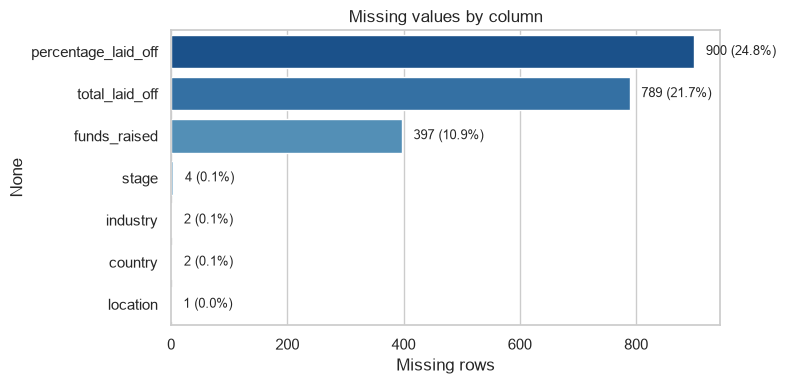

In [6]:
missing = clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(clean) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing.values, y=missing.index, hue=missing.index, palette="Blues_r", legend=False, ax=ax)
for i, (v, p) in enumerate(zip(missing.values, missing_pct.values)):
    ax.text(v + 20, i, f"{v:,} ({p}%)", va="center", fontsize=9)
ax.set_xlabel("Missing rows")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()


## 4. Layoffs over time

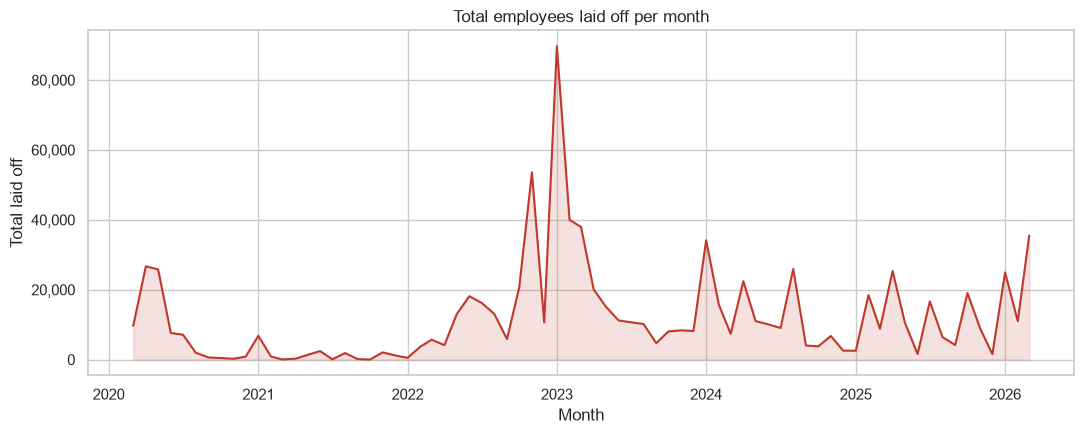

In [7]:
monthly = clean.groupby("year_month")["total_laid_off"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly["year_month"], monthly["total_laid_off"], color="#c0392b", linewidth=1.5)
ax.fill_between(monthly["year_month"], monthly["total_laid_off"], color="#c0392b", alpha=0.15)
ax.set_title("Total employees laid off per month")
ax.set_xlabel("Month")
ax.set_ylabel("Total laid off")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


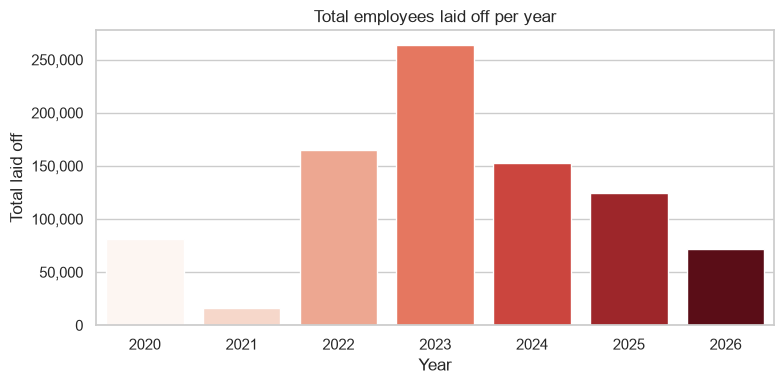

year
2020     80,998
2021     15,823
2022    165,269
2023    264,320
2024    152,922
2025    124,201
2026     71,447
Name: total_laid_off, dtype: object

In [8]:
yearly = clean.groupby("year")["total_laid_off"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=yearly.index.astype(int), y=yearly.values, hue=yearly.index.astype(int), palette="Reds", legend=False, ax=ax)
ax.set_title("Total employees laid off per year")
ax.set_xlabel("Year")
ax.set_ylabel("Total laid off")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

yearly.map(lambda x: f"{x:,.0f}")


## 5. Top companies & industries

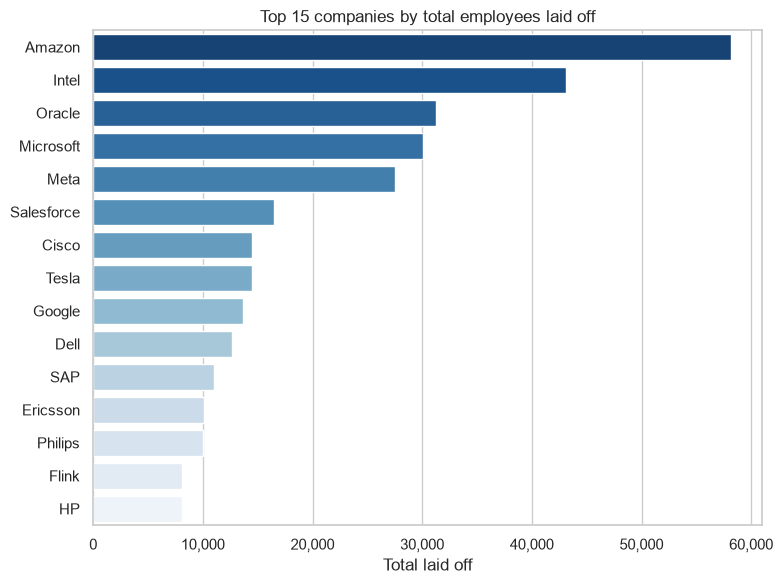

In [9]:
top_companies = (
    clean.groupby("company")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, hue=top_companies.index, palette="Blues_r", legend=False, ax=ax)
ax.set_title("Top 15 companies by total employees laid off")
ax.set_xlabel("Total laid off")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


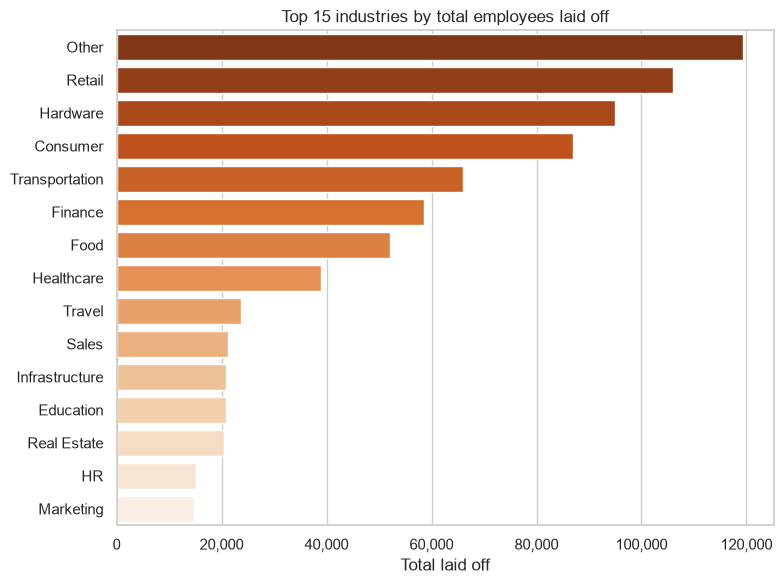

In [10]:
top_industries = (
    clean.groupby("industry")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_industries.values, y=top_industries.index, hue=top_industries.index, palette="Oranges_r", legend=False, ax=ax)
ax.set_title("Top 15 industries by total employees laid off")
ax.set_xlabel("Total laid off")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


## 6. Country & funding-stage breakdown

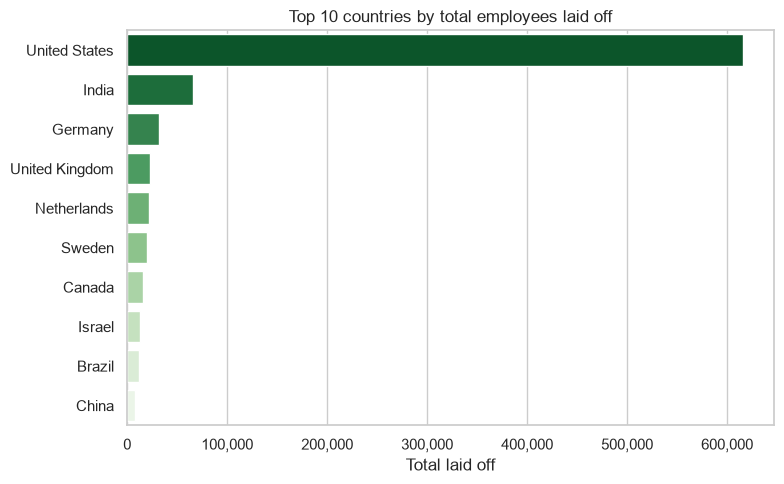

In [11]:
top_countries = (
    clean.groupby("country")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="Greens_r", legend=False, ax=ax)
ax.set_title("Top 10 countries by total employees laid off")
ax.set_xlabel("Total laid off")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


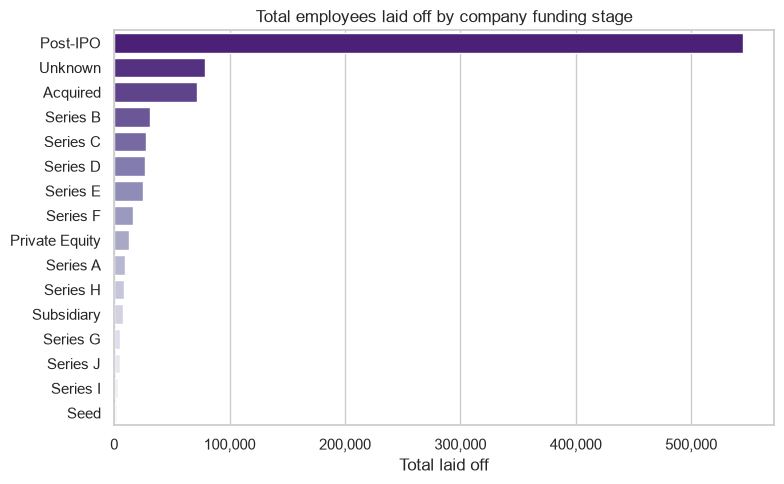

In [12]:
stage_totals = (
    clean.groupby("stage")["total_laid_off"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=stage_totals.values, y=stage_totals.index, hue=stage_totals.index, palette="Purples_r", legend=False, ax=ax)
ax.set_title("Total employees laid off by company funding stage")
ax.set_xlabel("Total laid off")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


## 7. Total laid off vs. percentage laid off

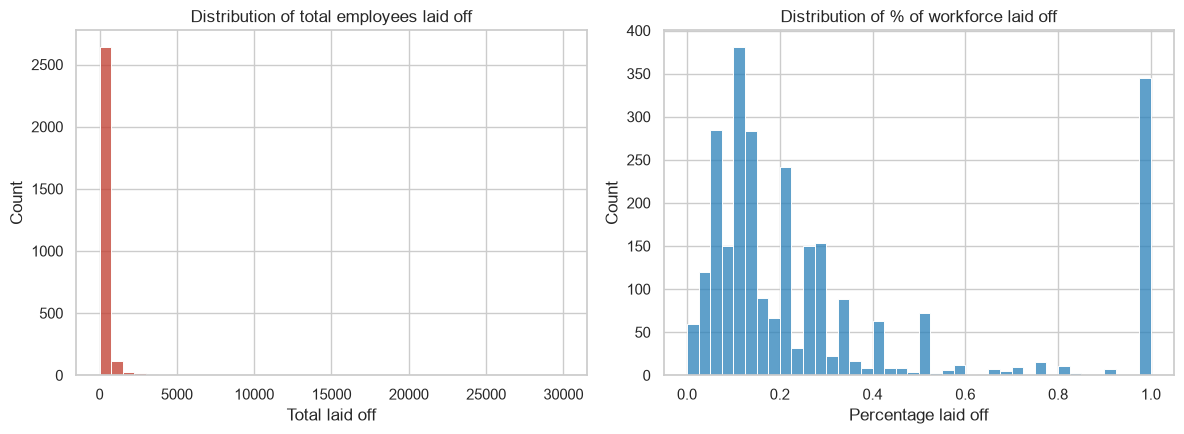

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(clean["total_laid_off"].dropna(), bins=40, color="#c0392b", ax=axes[0])
axes[0].set_title("Distribution of total employees laid off")
axes[0].set_xlabel("Total laid off")

sns.histplot(clean["percentage_laid_off"].dropna(), bins=40, color="#2980b9", ax=axes[1])
axes[1].set_title("Distribution of % of workforce laid off")
axes[1].set_xlabel("Percentage laid off")

plt.tight_layout()
plt.show()


In [14]:
fully_shut_down = clean[clean["percentage_laid_off"] == 1.0]
print(f"Companies that laid off 100% of staff (shut down): {fully_shut_down['company'].nunique()}")
fully_shut_down[["company", "industry", "country", "stage", "total_laid_off", "date"]].sort_values("date", ascending=False).head(10)


Companies that laid off 100% of staff (shut down): 342


,company,industry,country,stage,total_laid_off,date
3,Covrzy,Finance,India,Seed,NaN,2026-03-31
4,Rec Room,Consumer,United States,Series F,NaN,2026-03-31
5,Yupp,AI,United States,Seed,NaN,2026-03-31
16,FranShares,Finance,United States,Seed,NaN,2026-03-17
65,Entropy,Crypto,United States,Seed,NaN,2026-01-25
93,EyeEm,Other,Germany,Acquired,NaN,2025-12-11
98,GenWise,Other,India,Seed,NaN,2025-12-09
105,Inbound Health,Healthcare,United States,Series B,NaN,2025-12-01
118,BharatAgri,Food,India,Series A,37.0,2025-11-13
123,Sonder,Travel,United States,Post-IPO,NaN,2025-11-10


Correlation between funds raised and total laid off: 0.11


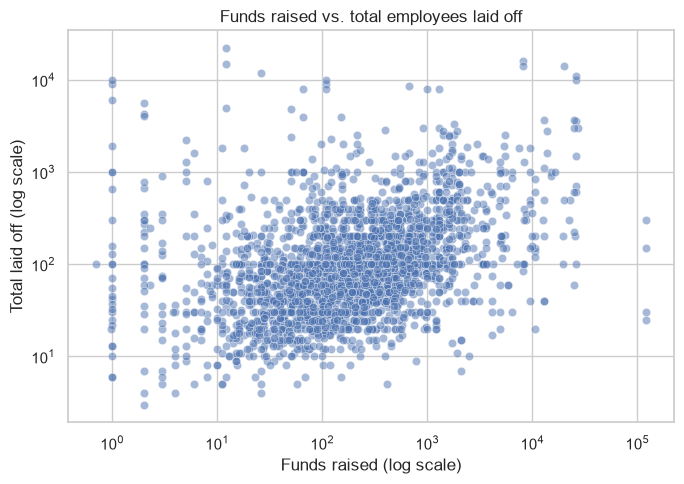

In [15]:
funded = clean.dropna(subset=["funds_raised", "total_laid_off"])
corr = funded["funds_raised"].corr(funded["total_laid_off"])
print(f"Correlation between funds raised and total laid off: {corr:.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=funded, x="funds_raised", y="total_laid_off", alpha=0.5, ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Funds raised (log scale)")
ax.set_ylabel("Total laid off (log scale)")
ax.set_title("Funds raised vs. total employees laid off")
plt.tight_layout()
plt.show()


## 8. Key takeaways

- **Data quality mirrors the SQL project's findings**: `total_laid_off` (~35%) and `percentage_laid_off` (~37%) are the most incomplete fields, followed by `funds_raised` (~11%) — consistent with why the SQL cleaning script keeps rows with partial null layoff data but drops rows missing *both* figures.
- **Layoffs cluster around macro shocks**: the sharpest monthly spikes line up with well-known waves — the initial COVID-19 shock (2020) and the big tech contraction (late 2022–2023).
- **A small number of companies dominate total headcount reductions** — large, publicly-traded tech firms (e.g. Amazon, Google, Meta, Microsoft, Intel) account for a disproportionate share of total employees laid off, even though most *events* in the dataset come from smaller companies.
- **Post-IPO / late-stage companies drive the largest layoff volumes** by headcount, while many of the 100%-workforce-loss events come from earlier-stage, smaller startups shutting down entirely.
- **Funds raised is only weakly correlated with layoff size** — well-funded companies aren't necessarily the ones cutting the most staff, suggesting layoff scale is driven more by company size/stage than by capital raised.

*Note: this dataset contains some dates beyond the documented 2020–2025 coverage window mentioned in the README; these are treated as-is and not filtered out in this notebook.*
